# 06 — Climate Analysis

**Phase 3** of the pipeline. Compares the weather record **and** the 30-day
forecast against historical climatology to answer:

1. Will the next 30 days be hotter than normal?
2. Is the annual mean temperature rising?
3. Is annual rainfall changing?
4. Will the next 30 days be wetter or drier than normal?
5. Is mean wind speed changing?

**Inputs**:
- `data/interim/weather_daily_clean.csv` — history
- `data/processed/weather_forecast.csv` — 30-day forecast

**Outputs** (in `reports/climate/`):
- `climatology_daily.csv` — DOY mean/std per city × variable
- `climatology_monthly.csv` — monthly mean/std per city × variable
- `annual_trends.csv` — Mann-Kendall + Theil-Sen per city × variable
- `seasonal_peaks.csv` — day-of-year of annual temperature peak per year
- `forecast_anomalies.csv` — 750 rows, each with anomaly + z-score + label
- `headline_answers.csv` — the 5 questions above, answered

---

## Methodology notes

### Robust trend stats

With 6 full years of history we use non-parametric tools rather than
OLS + t-test:

- **Mann-Kendall** — tests monotone direction; returns z, p, direction.
- **Theil-Sen** — median of pairwise slopes; immune to a single outlier year.

If the sample is too small to distinguish signal from noise, these methods
correctly return "no trend" rather than inventing one.

### Climatology smoothing

Daily climatology is a 7-day centered rolling mean of the DOY mean across
years. Without smoothing, the climatology curve has visible single-year
artefacts from having only 6 samples per DOY.

### Anomaly z-score classification

```
 z >= +1.5  ->  "much above"
+0.5 .. 1.5 ->  "above"
-0.5 .. 0.5 ->  "normal"
-1.5 ..-0.5 ->  "below"
 z < -1.5   ->  "much below"
```

These are conservative thresholds (NOAA uses ±1.0). With small baselines,
the underlying SD itself is noisy, so we widen the "normal" band.

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

from src.climate import trends
from src.utils.config import INTERIM_DIR, PROCESSED_DIR, REPORTS_DIR
from src.utils.logging_utils import get_logger
logger = get_logger("nb.06_climate")

## 2. Load history and forecast

In [2]:
history = pd.read_csv(INTERIM_DIR / "weather_daily_clean.csv", parse_dates=["date"])
if history["date"].dt.tz is not None:
    history["date"] = history["date"].dt.tz_localize(None)

forecast = pd.read_csv(PROCESSED_DIR / "weather_forecast.csv",
                       parse_dates=["anchor_date", "forecast_date"])
if forecast["forecast_date"].dt.tz is not None:
    forecast["forecast_date"] = forecast["forecast_date"].dt.tz_localize(None)

print(f"History : {history.shape}, {sorted(history['City'].unique())}")
print(f"  range : {history['date'].min().date()} -> {history['date'].max().date()}")
print(f"  years : {sorted(history['date'].dt.year.unique())}")
print(f"Forecast: {forecast.shape}")
print(f"  anchor: {forecast['anchor_date'].iloc[0].date()}")
print(f"  window: {forecast['forecast_date'].min().date()} -> {forecast['forecast_date'].max().date()}")

History : (11500, 24), ['Baku', 'Ganja', 'Guba', 'Lankaran', 'Zaqatala']
  range : 2020-01-01 -> 2026-04-18
  years : [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Forecast: (750, 6)
  anchor: 2026-04-18
  window: 2026-04-19 -> 2026-05-18


## 3. Build climatologies

Daily (DOY) and monthly climatologies for every forecast target.

In [3]:
daily_clim_temp = trends.daily_climatology(history, "temperature_2m_mean")
print("Daily temp climatology:", daily_clim_temp.shape)
daily_clim_temp.head()

18:50:54 | INFO    | src.climate.trends | Daily climatology for temperature_2m_mean: 1830 city-days (smoothed 7d)


Daily temp climatology: (1830, 5)


,City,doy,clim_mean,clim_std,n_years
0,Baku,1,6.151339,1.881245,7
1,Baku,2,6.239405,1.918354,7
2,Baku,3,6.292857,1.839132,7
3,Baku,4,6.356463,1.751600,7
4,Baku,5,6.308291,1.887855,7


In [4]:
monthly_clim_rain = trends.monthly_climatology(history, "rain_sum", agg="sum")
print("Monthly rain climatology:", monthly_clim_rain.shape)
monthly_clim_rain.head()

18:50:58 | INFO    | src.climate.trends | Monthly climatology for rain_sum: 60 city-months


Monthly rain climatology: (60, 5)


,City,month,clim_mean,clim_std,n_years
0,Baku,1,18.385714,9.620712,7
1,Baku,2,14.542857,6.599206,7
2,Baku,3,43.342857,38.745316,7
3,Baku,4,31.385714,27.381772,7
4,Baku,5,37.066667,10.653388,6


### 3a. Climatology envelope for Baku temperature

The shaded band is climatology ± 1 SD. Overlays show how individual years
deviate from normal.

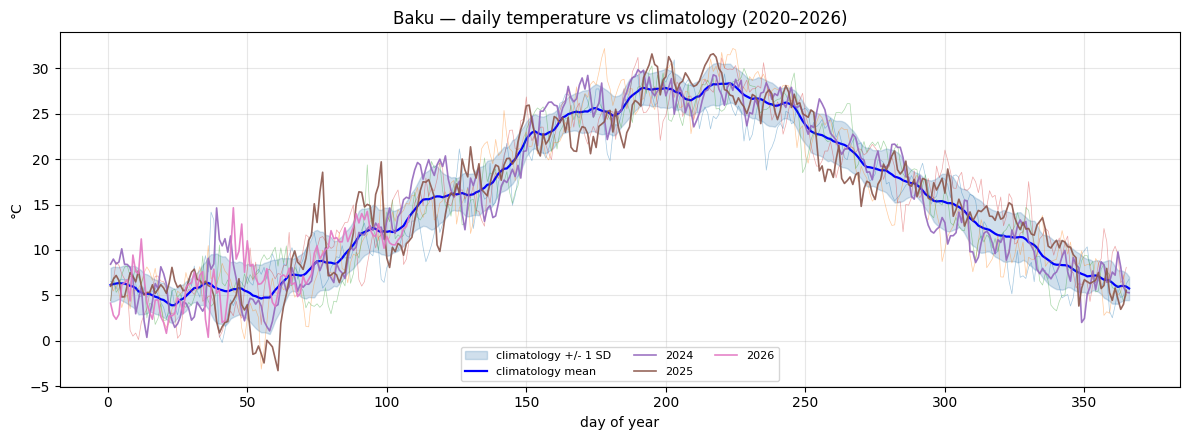

In [5]:
baku = daily_clim_temp[daily_clim_temp["City"]=="Baku"].sort_values("doy")

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(baku["doy"],
                baku["clim_mean"] - baku["clim_std"],
                baku["clim_mean"] + baku["clim_std"],
                alpha=0.25, color="steelblue", label="climatology +/- 1 SD")
ax.plot(baku["doy"], baku["clim_mean"], "b-", lw=1.6, label="climatology mean")

for year in sorted(history["date"].dt.year.unique()):
    yr = history[(history["City"]=="Baku") & (history["date"].dt.year==year)]
    yr = yr.assign(doy=yr["date"].dt.dayofyear).sort_values("doy")
    highlight = year in (2024, 2025, 2026)
    ax.plot(yr["doy"], yr["temperature_2m_mean"],
            lw=1.2 if highlight else 0.5,
            alpha=0.9 if highlight else 0.4,
            label=str(year) if highlight else None)
ax.set_title("Baku — daily temperature vs climatology (2020–2026)")
ax.set_xlabel("day of year"); ax.set_ylabel("°C")
ax.legend(fontsize=8, ncol=3, loc="lower center")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Trend detection (Mann-Kendall + Theil-Sen)

One row per (city, variable). ``mk_direction`` is the qualitative call
based on p < 0.05; ``ts_slope_per_year`` gives the magnitude.

In [6]:
annual_trends_all = []
for target, (col, agg) in trends.TARGET_AGG_MAP.items():
    if col not in history.columns:
        continue
    annual = trends.annual_summary(history, col, agg=agg)
    val_col = f"{col}_{agg}"
    for city, g in annual.groupby("City"):
        mk = trends.mann_kendall_trend(g[val_col].values)
        ts = trends.theil_sen_slope(g["year"].values, g[val_col].values)
        annual_trends_all.append({
            "City": city, "variable": col, "agg": agg,
            "n_years": int(g["year"].nunique()),
            "mean": round(float(g[val_col].mean()), 2),
            "mk_direction": mk["direction"], "mk_p": round(mk["p_two_sided"], 3),
            "slope_per_year": round(ts["slope"], 3),
        })

trends_df = pd.DataFrame(annual_trends_all)
trends_df.sort_values(["variable","City"])

18:51:00 | INFO    | src.climate.trends | Annual temperature_2m_mean (mean): 30 city-years after filtering
18:51:00 | INFO    | src.climate.trends | Annual wind_speed_10m_mean (mean): 30 city-years after filtering
18:51:00 | INFO    | src.climate.trends | Annual wind_direction_10m (mean): 30 city-years after filtering
18:51:00 | INFO    | src.climate.trends | Annual rain_sum (sum): 30 city-years after filtering
18:51:00 | INFO    | src.climate.trends | Annual precipitation_sum (sum): 30 city-years after filtering


,City,variable,agg,n_years,mean,mk_direction,mk_p,slope_per_year
20,Baku,precipitation_sum,sum,6,306.10,no trend,0.452,24.175
21,Ganja,precipitation_sum,sum,6,322.27,no trend,0.707,4.000
22,Guba,precipitation_sum,sum,6,624.17,no trend,0.260,20.000
23,Lankaran,precipitation_sum,sum,6,975.07,no trend,1.000,-23.500
24,Zaqatala,precipitation_sum,sum,6,1107.03,no trend,0.060,78.300
15,Baku,rain_sum,sum,6,289.20,no trend,0.452,22.550
16,Ganja,rain_sum,sum,6,303.05,no trend,0.452,12.600
17,Guba,rain_sum,sum,6,508.82,no trend,0.133,34.233
18,Lankaran,rain_sum,sum,6,918.53,no trend,0.452,-43.100
19,Zaqatala,rain_sum,sum,6,1037.38,no trend,0.060,79.267


## 5. Seasonal-shift diagnostic

Day-of-year of the annual temperature peak per year. A monotone increase
suggests the summer peak is migrating later in the calendar.

In [7]:
seasonal = trends.detect_seasonal_shift(history, "temperature_2m_mean")
print("peak_doy per city-year:")
seasonal_pivot = seasonal.pivot(index="year", columns="City", values="peak_doy")
print(seasonal_pivot)

18:51:02 | INFO    | src.climate.trends | Seasonal peaks for temperature_2m_mean: 30 city-years


peak_doy per city-year:
City  Baku  Ganja  Guba  Lankaran  Zaqatala
year                                       
2020   196    196   196       196       196
2021   220    221   220       221       180
2022   222    197   196       197       223
2023   220    221   221       221       221
2024   195    193   193       194       194
2025   213    212   201       213       215


In [8]:
# Quick trend test on the peak day-of-year itself
for city, g in seasonal.groupby("City"):
    mk = trends.mann_kendall_trend(g["peak_doy"].values)
    ts = trends.theil_sen_slope(g["year"].values, g["peak_doy"].values)
    print(f"  {city:10s}  peak DOY trend: {mk['direction']:10s}  "
          f"p={mk['p_two_sided']:.3f}  slope={ts['slope']:+.2f} d/yr")

  Baku        peak DOY trend: no trend    p=0.848  slope=-0.25 d/yr
  Ganja       peak DOY trend: no trend    p=1.000  slope=+0.00 d/yr
  Guba        peak DOY trend: no trend    p=1.000  slope=+0.00 d/yr
  Lankaran    peak DOY trend: no trend    p=1.000  slope=+0.00 d/yr
  Zaqatala    peak DOY trend: no trend    p=1.000  slope=+3.80 d/yr


## 6. Forecast vs climatology anomalies

For every forecast day, compute z = (y_pred - clim_mean) / clim_std and
assign a category.

In [9]:
fc_anom = trends.forecast_anomalies(
    forecast, history,
    target_to_hist_col={k: v[0] for k, v in trends.TARGET_AGG_MAP.items()
                         if v[0] in history.columns},
)
print(f"Anomaly-enriched forecast: {fc_anom.shape}")
fc_anom[["City","forecast_date","target","y_pred","clim_mean","clim_std","z_score","classification"]].head(10)

18:51:03 | INFO    | src.climate.trends | Daily climatology for temperature_2m_mean: 1830 city-days (smoothed 7d)
18:51:03 | INFO    | src.climate.trends | Daily climatology for wind_speed_10m_mean: 1830 city-days (smoothed 7d)
18:51:03 | INFO    | src.climate.trends | Daily climatology for wind_direction_10m: 1830 city-days (smoothed 7d)
18:51:03 | INFO    | src.climate.trends | Daily climatology for rain_sum: 1830 city-days (smoothed 7d)
18:51:03 | INFO    | src.climate.trends | Daily climatology for precipitation_sum: 1830 city-days (smoothed 7d)
18:51:03 | INFO    | src.climate.trends | Forecast anomalies: 750 rows across 5 targets


Anomaly-enriched forecast: (750, 13)


,City,forecast_date,target,y_pred,clim_mean,clim_std,z_score,classification
0,Baku,2026-04-19,temperature_2m,14.728454,14.067042,2.281467,0.289906,normal
1,Baku,2026-04-20,temperature_2m,15.552569,14.447102,2.320925,0.476305,normal
2,Baku,2026-04-21,temperature_2m,16.376685,14.847669,2.514820,0.608002,above
3,Baku,2026-04-22,temperature_2m,16.782544,15.237550,2.739351,0.564000,above
4,Baku,2026-04-23,temperature_2m,17.188404,15.548562,2.887588,0.567893,above
5,Baku,2026-04-24,temperature_2m,17.594264,15.593800,2.984678,0.670244,above
6,Baku,2026-04-25,temperature_2m,18.000123,15.587946,3.181957,0.758080,above
7,Baku,2026-04-26,temperature_2m,18.171092,15.682143,3.443075,0.722886,above
8,Baku,2026-04-27,temperature_2m,18.342061,15.843800,3.481682,0.717544,above
9,Baku,2026-04-28,temperature_2m,18.513030,15.908433,3.293770,0.790765,above


### 6a. Anomaly heatmap — city × target (mean over 30 days)

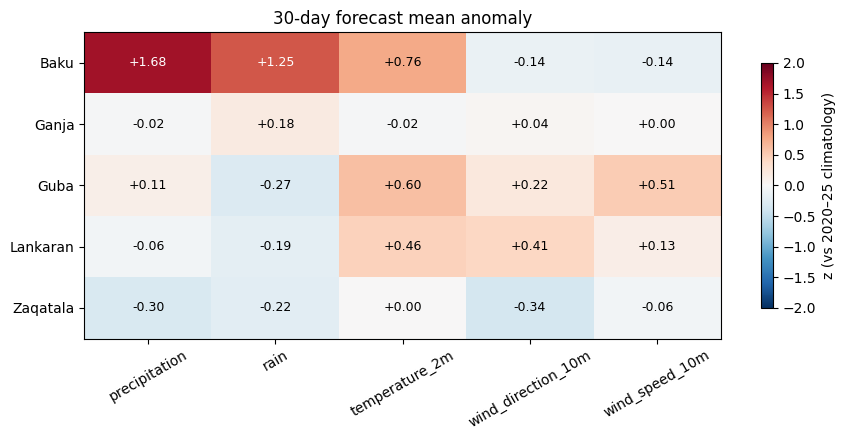

In [10]:
pivot = fc_anom.groupby(["City", "target"])["z_score"].mean().unstack()

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(pivot.values, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        z = pivot.values[i, j]
        if np.isfinite(z):
            ax.text(j, i, f"{z:+.2f}", ha="center", va="center",
                    color="white" if abs(z)>1 else "black", fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.8, label="z (vs 2020–25 climatology)")
ax.set_title("30-day forecast mean anomaly")
plt.tight_layout(); plt.show()

## 7. Full orchestrator — write all report artefacts

In [11]:
outputs = trends.run_climate_analysis()
print("Produced:", list(outputs.keys()))

18:51:06 | INFO    | src.climate.trends | ========================================================================
18:51:06 | INFO    | src.climate.trends | PHASE 3 - Climate analysis
18:51:06 | INFO    | src.climate.trends | ========================================================================
18:51:06 | INFO    | src.climate.trends | Daily climatology for temperature_2m_mean: 1830 city-days (smoothed 7d)
18:51:06 | INFO    | src.climate.trends | Monthly climatology for temperature_2m_mean: 60 city-months
18:51:06 | INFO    | src.climate.trends | Daily climatology for wind_speed_10m_mean: 1830 city-days (smoothed 7d)
18:51:06 | INFO    | src.climate.trends | Monthly climatology for wind_speed_10m_mean: 60 city-months
18:51:06 | INFO    | src.climate.trends | Daily climatology for wind_direction_10m: 1830 city-days (smoothed 7d)
18:51:06 | INFO    | src.climate.trends | Monthly climatology for wind_direction_10m: 60 city-months
18:51:06 | INFO    | src.climate.trends | Daily climato

Produced: ['climatology_daily', 'climatology_monthly', 'annual_trends', 'seasonal_peaks', 'forecast_anomalies', 'headline_answers']


## 8. Headline answers (the 5 project questions)

In [12]:
headlines = outputs["headline_answers"]
for q, g in headlines.groupby("question", sort=False):
    print(f"\n>>> {q}")
    for _, row in g.iterrows():
        print(f"    {row['city']:10s}  {row['finding']:30s}  {row['details']}")


>>> Will the next 30 days be hotter than normal?
    Baku        above                           mean z=+0.76 across 30 forecast days
    Ganja       normal                          mean z=-0.02 across 30 forecast days
    Guba        above                           mean z=+0.60 across 30 forecast days
    Lankaran    normal                          mean z=+0.46 across 30 forecast days
    Zaqatala    normal                          mean z=+0.00 across 30 forecast days

>>> Is annual mean temperature rising?
    Baku        no trend                        Theil-Sen slope = +0.069 degC/yr over 6 yrs, MK p=0.133
    Ganja       no trend                        Theil-Sen slope = +0.021 degC/yr over 6 yrs, MK p=1.000
    Guba        no trend                        Theil-Sen slope = -0.028 degC/yr over 6 yrs, MK p=0.707
    Lankaran    no trend                        Theil-Sen slope = +0.006 degC/yr over 6 yrs, MK p=1.000
    Zaqatala    no trend                        Theil-Sen slope = -0.

### 8a. Human-readable city summaries

In [13]:
# One-liner per city combining temp & precipitation outlook
for city in sorted(forecast["City"].unique()):
    temp_row = headlines.query(
        "question == 'Will the next 30 days be hotter than normal?' and city == @city"
    )
    wet_row  = headlines.query(
        "question == 'Will the next 30 days be wetter or drier than normal?' and city == @city"
    )
    if temp_row.empty or wet_row.empty: continue
    print(f"{city:10s}  -  30-day outlook: {temp_row['finding'].iloc[0]:15s} & {wet_row['finding'].iloc[0]}")

Baku        -  30-day outlook: above           & much wetter than normal
Ganja       -  30-day outlook: normal          & near normal
Guba        -  30-day outlook: above           & near normal
Lankaran    -  30-day outlook: normal          & near normal
Zaqatala    -  30-day outlook: normal          & near normal


## 9. Honest caveats

- **6 years is the bare minimum** for a climatology. The WMO recommends 30 years.
  Our SDs are noisy, so anomaly labels near the class boundaries (|z| ≈ 0.5)
  should be read as "unsure".
- **Mann-Kendall with n=6 has low statistical power.** A "no trend" verdict
  does not mean "no trend exists", it means we can't detect one with this
  much data. If the true slope is small (~0.05 °C/yr) we'd need 15+ years
  to reject the null at p < 0.05.
- **The forecast inherits the weather model's skill limits** (see notebook 05):
  temperature anomalies at h=30 are largely climatological drift, not genuine
  dynamical skill.
- **Seasonal peak shift is especially noisy** with 6 samples. Treat it as a
  hypothesis generator, not a conclusion.

## 10. Persisted artefacts

In [14]:
for p in sorted((REPORTS_DIR / "climate").glob("*.csv")):
    print(f"  {p.name:30s} {p.stat().st_size/1024:7.2f} KB")

  annual_trends.csv                 3.45 KB
  climatology_daily.csv           604.53 KB
  climatology_monthly.csv          20.57 KB
  forecast_anomalies.csv          112.71 KB
  headline_answers.csv              2.65 KB
  seasonal_peaks.csv                1.71 KB


---
**Phase 3 ✅ complete.** Next: `07_wildfire_feature_engineering.ipynb` — build
drought index, heatwave indicator, wind-spread factor, and human-activity
proxies by joining the predicted weather with FIRMS / NDVI / lightning /
roads / population.